# Gesture Recognition - Model Training

This notebook handles model definition, training, and evaluation.

**Output:** Trained model weights (.pth)

## 1. Environment Setup

In [23]:
# Check GPU
!nvidia-smi

/bin/bash: line 1: nvidia-smi: command not found


In [24]:
import os
import json
import random
from collections import defaultdict

import cv2
import numpy as np
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from sklearn.metrics import classification_report, confusion_matrix, f1_score

import matplotlib.pyplot as plt

from datetime import datetime


def log_info(msg):
    """Print INFO message with timestamp."""
    ts = datetime.now().strftime("%H:%M:%S")
    print(f"[{ts}] INFO - {msg}")


def log_warn(msg):
    """Print WARNING message with timestamp."""
    ts = datetime.now().strftime("%H:%M:%S")
    print(f"[{ts}] WARNING - {msg}")

## 2. Mount Google Drive and Load Dataset Info

In [25]:
# Mount Google Drive
from google.colab import drive

drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [26]:
# Load dataset info
save_dir = "checkpoints"
info_path = os.path.join(save_dir, "dataset_info.json")

with open(info_path, "r", encoding="utf-8") as f:
    dataset_info = json.load(f)

# Set constants from dataset_info
SEQ_LEN = dataset_info["seq_len"]
FEATURE_DIM = dataset_info["feature_dim"]
RAW_DIM = dataset_info["raw_dim"]
NUM_CLASSES = dataset_info["num_classes"]
CLASS_NAMES = dataset_info["class_names"]
CACHE_VERSION = dataset_info["cache_version"]
PAIRS = [tuple(p) for p in dataset_info["pairs"]]
FINGER_CHAINS = dataset_info["finger_chains"]
N_FINGERS = dataset_info["n_fingers"]
N_PAIRS = len(PAIRS)
NUM_LANDMARKS = 21
NUM_COORDS = 3
WRIST_IDX = 0
MID_FINGER_IDX = 9

# Training hyperparameters
BATCH_SIZE = 32
EPOCHS = 300
LR = 2e-3
WEIGHT_DECAY = 1e-3
PATIENCE = 40

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Device: {DEVICE}")
print(f"Feature dim: {FEATURE_DIM}")
print(f"Classes: {CLASS_NAMES}")

Device: cpu
Feature dim: 144
Classes: ['grab', 'release', 'swipe_up', 'swipe_down', 'noise']


## 3. Load Preprocessed Data

In [27]:
def to_scalar(v, default=None):
    if v is None:
        return default
    if isinstance(v, np.ndarray):
        if v.shape == ():
            v = v.item()
        elif v.size == 1:
            v = v.reshape(()).item()
    if isinstance(v, bytes):
        return v.decode("utf-8")
    return v


def resample(seq, target=SEQ_LEN):
    seq = np.asarray(seq, dtype=np.float32)
    if seq.ndim != 2:
        return np.zeros((target, RAW_DIM), dtype=np.float32)
    n, d = seq.shape
    if n == 0:
        return np.zeros((target, d), dtype=np.float32)
    if n == target:
        return seq.copy()
    x_old = np.linspace(0.0, 1.0, n, dtype=np.float32)
    x_new = np.linspace(0.0, 1.0, target, dtype=np.float32)
    out = np.zeros((target, d), dtype=np.float32)
    for i in range(d):
        out[:, i] = np.interp(x_new, x_old, seq[:, i]).astype(np.float32)
    return out


def to_raw_sequence(seq, target_len=None):
    try:
        arr = np.asarray(seq, dtype=np.float32)
    except Exception:
        return None
    if arr.size == 0:
        t = 0 if target_len is None else target_len
        return np.zeros((t, RAW_DIM), dtype=np.float32)
    if arr.ndim == 3 and arr.shape[1] == NUM_LANDMARKS and arr.shape[2] == NUM_COORDS:
        arr = arr.reshape(arr.shape[0], RAW_DIM)
    elif arr.ndim == 2 and arr.shape == (NUM_LANDMARKS, NUM_COORDS):
        arr = arr.reshape(1, RAW_DIM)
    elif arr.ndim == 2 and arr.shape[1] == RAW_DIM:
        pass
    elif arr.ndim == 2 and arr.shape[0] == RAW_DIM and arr.shape[1] != RAW_DIM:
        arr = arr.T
        if arr.shape[1] != RAW_DIM:
            return None
    elif arr.ndim == 1 and arr.size % RAW_DIM == 0:
        arr = arr.reshape(-1, RAW_DIM)
    else:
        return None
    arr = np.ascontiguousarray(arr, dtype=np.float32)
    if target_len is not None and arr.shape[0] != target_len:
        arr = resample(arr, target_len)
    return arr

In [28]:
def compute_features(raw_seq):
    """Compute feature vector from raw landmark sequence."""
    raw_seq = to_raw_sequence(raw_seq)
    if raw_seq is None:
        shape = np.asarray(raw_seq).shape if raw_seq is not None else None
        raise ValueError(f"Invalid raw sequence shape: {shape}")
    T = raw_seq.shape[0]
    if T == 0:
        return np.zeros((0, FEATURE_DIM), dtype=np.float32)
    lms = raw_seq.reshape(T, NUM_LANDMARKS, NUM_COORDS)
    wrist = lms[:, WRIST_IDX, :]
    relative = lms - wrist[:, np.newaxis, :]
    mid = lms[:, MID_FINGER_IDX, :]
    palm_size = np.maximum(np.linalg.norm(mid - wrist, axis=-1, keepdims=True), 1e-6)
    norm_lms = relative / palm_size[:, np.newaxis, :]
    norm_flat = norm_lms.reshape(T, -1).astype(np.float32)
    vel = np.zeros_like(norm_flat)
    if T > 1:
        vel[1:] = norm_flat[1:] - norm_flat[:-1]
        vel[0] = vel[1]
    wrist_vel = np.zeros((T, 3), dtype=np.float32)
    if T > 1:
        wrist_vel[1:] = wrist[1:] - wrist[:-1]
        wrist_vel[0] = wrist_vel[1]
    dists = np.zeros((T, N_PAIRS), dtype=np.float32)
    for k, (i, j) in enumerate(PAIRS):
        dists[:, k] = np.linalg.norm(norm_lms[:, i] - norm_lms[:, j], axis=-1)
    angles = np.zeros((T, N_FINGERS), dtype=np.float32)
    for fi, chain in enumerate(FINGER_CHAINS):
        v1 = lms[:, chain[1]] - lms[:, chain[0]]
        v2 = lms[:, chain[-1]] - lms[:, chain[1]]
        n1 = np.linalg.norm(v1, axis=-1, keepdims=True) + 1e-8
        n2 = np.linalg.norm(v2, axis=-1, keepdims=True) + 1e-8
        cos_a = np.clip((v1 / n1 * v2 / n2).sum(-1), -1.0, 1.0)
        angles[:, fi] = np.arccos(cos_a)
    feat = np.concatenate([norm_flat, vel, wrist_vel, dists, angles], axis=1)
    return feat.astype(np.float32)

In [29]:
# Load cache
cache_dir = os.path.join(save_dir, "cache")
tr_cache = os.path.join(cache_dir, f"train_{CACHE_VERSION}.npz")
te_cache = os.path.join(cache_dir, f"test_{CACHE_VERSION}.npz")


def load_cache(cache_path):
    log_info(f"Loading cache: {cache_path}")
    with np.load(cache_path, allow_pickle=True) as c:
        samples = np.asarray(c["samples"], dtype=np.float32)
        labels = np.asarray(c["labels"], dtype=np.int64)
    out_samples = [np.ascontiguousarray(s, dtype=np.float32) for s in samples]
    out_labels = labels.astype(np.int64).tolist()
    log_info(f"  {len(out_samples)} samples loaded")
    return out_samples, out_labels


train_samples, train_labels = load_cache(tr_cache)
test_samples, test_labels = load_cache(te_cache)

print(f"Train samples: {len(train_samples)}")
print(f"Test samples: {len(test_samples)}")

[00:33:25] INFO - Loading cache: checkpoints/cache/train_v3_fixed_swipe_reverse.npz
[00:33:25] INFO -   3018 samples loaded
[00:33:25] INFO - Loading cache: checkpoints/cache/test_v3_fixed_swipe_reverse.npz
[00:33:25] INFO -   29 samples loaded
Train samples: 3018
Test samples: 29


In [30]:
# Load normalization stats
norm_stats = torch.load(os.path.join(save_dir, "norm_stats.pt"), weights_only=False)
print(
    f"Loaded norm_stats: mean shape={norm_stats['mean'].shape}, std shape={norm_stats['std'].shape}"
)

Loaded norm_stats: mean shape=(144,), std shape=(144,)


## 4. PyTorch Dataset and DataLoader

In [31]:
def add_jitter(raw_seq, sigma=0.003):
    raw = to_raw_sequence(raw_seq)
    if raw is None:
        raise ValueError("Invalid raw sequence for add_jitter")
    noise = np.random.randn(*raw.shape).astype(np.float32) * sigma
    return (raw + noise).astype(np.float32)


def time_warp(raw_seq):
    raw = to_raw_sequence(raw_seq)
    if raw is None:
        raise ValueError("Invalid raw sequence for time_warp")
    n = len(raw)
    if n < 4:
        return raw.copy()
    anchor = np.random.uniform(0.3, 0.7)
    warp = np.random.uniform(0.8, 1.2)
    x = np.linspace(0.0, 1.0, n, dtype=np.float32)
    x_new = np.where(
        x < anchor,
        x * warp,
        anchor * warp + (x - anchor) * (1.0 - anchor * warp) / (1.0 - anchor + 1e-8),
    )
    x_new = np.clip(x_new, 0.0, 1.0)
    out = np.zeros_like(raw)
    x_target = np.linspace(0.0, 1.0, n, dtype=np.float32)
    for d in range(raw.shape[1]):
        out[:, d] = np.interp(x_target, x_new, raw[:, d]).astype(np.float32)
    return out.astype(np.float32)

In [32]:
class GestureDataset(Dataset):
    def __init__(self, raw_samples, labels, norm_stats=None, augment=False):
        self.raw_samples = raw_samples
        self.labels = labels
        self.norm_stats = norm_stats
        self.augment = augment

    def __len__(self):
        return len(self.raw_samples)

    def __getitem__(self, idx):
        raw = self.raw_samples[idx].copy()
        label = self.labels[idx]
        if self.augment and random.random() < 0.5:
            raw = add_jitter(raw, sigma=0.002)
        if self.augment and random.random() < 0.3:
            raw = time_warp(raw)
            raw = resample(raw, SEQ_LEN)
        feat = compute_features(raw)
        if self.norm_stats is not None:
            feat = (feat - self.norm_stats["mean"]) / (self.norm_stats["std"] + 1e-8)
        x = torch.FloatTensor(feat.T)
        y = torch.tensor(label, dtype=torch.long)
        return x, y


def compute_class_weights(labels):
    counts = np.bincount(labels, minlength=NUM_CLASSES).astype(float)
    counts = np.maximum(counts, 1.0)
    w = counts.sum() / (NUM_CLASSES * counts)
    w = w / w.sum() * NUM_CLASSES
    return torch.FloatTensor(w)


def make_sampler(labels):
    counts = np.bincount(labels, minlength=NUM_CLASSES).astype(float)
    counts = np.maximum(counts, 1.0)
    sw = [1.0 / counts[l] for l in labels]
    return WeightedRandomSampler(sw, len(sw), replacement=True)

In [33]:
# Create dataloaders
class_weights = compute_class_weights(train_labels)
print(f"Class weights: {class_weights.numpy().round(3)}")

sampler = make_sampler(train_labels)
train_dataset = GestureDataset(train_samples, train_labels, norm_stats, augment=True)
test_dataset = GestureDataset(test_samples, test_labels, norm_stats, augment=False)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    sampler=sampler,
    num_workers=0,
    pin_memory=(DEVICE.type == "cuda"),
)
test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
)

print(f"Train batches: {len(train_loader)}")
print(f"Test batches: {len(test_loader)}")

Class weights: [0.969 0.867 1.259 1.016 0.889]
Train batches: 95
Test batches: 1


## 5. Model Definition (GestureTCN)

In [34]:
class CausalConv1d(nn.Module):
    def __init__(self, in_ch, out_ch, ks, dilation=1):
        super().__init__()
        self.pad = (ks - 1) * dilation
        self.conv = nn.Conv1d(
            in_ch, out_ch, ks, padding=self.pad, dilation=dilation, bias=False
        )

    def forward(self, x):
        o = self.conv(x)
        if self.pad > 0:
            o = o[:, :, : -self.pad]
        return o


class ResBlock(nn.Module):
    def __init__(self, ch, ks=3, dilation=1, dropout=0.15):
        super().__init__()
        self.net = nn.Sequential(
            CausalConv1d(ch, ch, ks, dilation),
            nn.BatchNorm1d(ch),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            CausalConv1d(ch, ch, ks, dilation),
            nn.BatchNorm1d(ch),
        )
        self.act = nn.ReLU(inplace=True)

    def forward(self, x):
        return self.act(self.net(x) + x)


class ChannelBlock(nn.Module):
    def __init__(self, in_ch, out_ch, ks=3, dilation=1, dropout=0.15):
        super().__init__()
        self.net = nn.Sequential(
            CausalConv1d(in_ch, out_ch, ks, dilation),
            nn.BatchNorm1d(out_ch),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            CausalConv1d(out_ch, out_ch, ks, dilation),
            nn.BatchNorm1d(out_ch),
        )
        self.skip = nn.Sequential(
            nn.Conv1d(in_ch, out_ch, 1, bias=False),
            nn.BatchNorm1d(out_ch),
        )
        self.act = nn.ReLU(inplace=True)

    def forward(self, x):
        return self.act(self.net(x) + self.skip(x))


class GestureTCN(nn.Module):
    def __init__(self, num_classes=NUM_CLASSES, feat_dim=FEATURE_DIM, dropout=0.15):
        super().__init__()
        self.stem = nn.Sequential(
            nn.Conv1d(feat_dim, 48, 1, bias=False),
            nn.BatchNorm1d(48),
            nn.ReLU(inplace=True),
        )
        self.blocks = nn.Sequential(
            ResBlock(48, 3, 1, dropout),
            ResBlock(48, 3, 2, dropout),
            ChannelBlock(48, 64, 3, 4, dropout),
            ResBlock(64, 3, 1, dropout),
        )
        self.pool = nn.AdaptiveAvgPool1d(1)
        self.head = nn.Sequential(
            nn.Linear(64, 32),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(32, num_classes),
        )
        self._init()

    def _init(self):
        for m in self.modules():
            if isinstance(m, nn.Conv1d):
                nn.init.kaiming_normal_(m.weight, nonlinearity="relu")
            elif isinstance(m, nn.BatchNorm1d):
                nn.init.ones_(m.weight)
                nn.init.zeros_(m.bias)
            elif isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight, nonlinearity="relu")
                if m.bias is not None:
                    nn.init.zeros_(m.bias)

    def forward(self, x):
        x = self.stem(x)
        x = self.blocks(x)
        x = self.pool(x).squeeze(-1)
        return self.head(x)

In [35]:
# Create model
model = GestureTCN(NUM_CLASSES, FEATURE_DIM, dropout=0.15).to(DEVICE)
total_params = sum(p.numel() for p in model.parameters())
print(f"Model params: {total_params:,}")
print(model)

Model params: 87,077
GestureTCN(
  (stem): Sequential(
    (0): Conv1d(144, 48, kernel_size=(1,), stride=(1,), bias=False)
    (1): BatchNorm1d(48, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
  )
  (blocks): Sequential(
    (0): ResBlock(
      (net): Sequential(
        (0): CausalConv1d(
          (conv): Conv1d(48, 48, kernel_size=(3,), stride=(1,), padding=(2,), bias=False)
        )
        (1): BatchNorm1d(48, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU(inplace=True)
        (3): Dropout(p=0.15, inplace=False)
        (4): CausalConv1d(
          (conv): Conv1d(48, 48, kernel_size=(3,), stride=(1,), padding=(2,), bias=False)
        )
        (5): BatchNorm1d(48, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (act): ReLU(inplace=True)
    )
    (1): ResBlock(
      (net): Sequential(
        (0): CausalConv1d(
          (conv): Conv1d(48, 48, kernel_size=(3,), stri

## 6. Training Loop

In [36]:
@torch.no_grad()
def evaluate(model, loader, criterion, device):
    if loader is None:
        return 0.0, 0.0, [], []
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    preds_all, labels_all = [], []
    for bx, by in loader:
        bx, by = bx.to(device), by.to(device)
        logits = model(bx)
        loss = criterion(logits, by)
        total_loss += loss.item() * bx.size(0)
        p = logits.argmax(1)
        correct += (p == by).sum().item()
        total += bx.size(0)
        preds_all.extend(p.cpu().numpy())
        labels_all.extend(by.cpu().numpy())
    if total == 0:
        return 0.0, 0.0, preds_all, labels_all
    return total_loss / total, correct / total, preds_all, labels_all

In [37]:
# Training setup
ckpt_path = os.path.join(save_dir, "gesture_tcn_best.pth")

# Loss and optimizer
try:
    criterion = nn.CrossEntropyLoss(
        weight=class_weights.to(DEVICE), label_smoothing=0.1
    )
except TypeError:
    criterion = nn.CrossEntropyLoss(weight=class_weights.to(DEVICE))

optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=1e-5)

best_acc = -1.0
best_epoch = 0
patience_ctr = 0

# For plotting
train_losses = []
test_losses = []
train_accs = []
test_accs = []
learning_rates = []

In [38]:
# Training loop
log_info("Training ...")

for epoch in range(1, EPOCHS + 1):
    model.train()
    t_loss, t_correct, t_total = 0.0, 0, 0
    for bx, by in train_loader:
        bx, by = bx.to(DEVICE), by.to(DEVICE)
        optimizer.zero_grad()
        logits = model(bx)
        loss = criterion(logits, by)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 2.0)
        optimizer.step()
        t_loss += loss.item() * bx.size(0)
        t_correct += (logits.argmax(1) == by).sum().item()
        t_total += bx.size(0)

    scheduler.step()

    tr_loss = t_loss / max(t_total, 1)
    tr_acc = t_correct / max(t_total, 1)
    te_loss, te_acc, _, _ = evaluate(model, test_loader, criterion, DEVICE)
    lr_now = optimizer.param_groups[0]["lr"]

    # Record for plotting
    train_losses.append(tr_loss)
    test_losses.append(te_loss)
    train_accs.append(tr_acc)
    test_accs.append(te_acc)
    learning_rates.append(lr_now)

    tag = ""
    if te_acc > best_acc:
        best_acc = te_acc
        best_epoch = epoch
        patience_ctr = 0
        torch.save(model.state_dict(), ckpt_path)
        tag = "  <- best"
    else:
        patience_ctr += 1

    if epoch % 5 == 0 or tag:
        log_info(
            f"Epoch {epoch:>3d}/{EPOCHS} | "
            f"TrL:{tr_loss:.4f} TrA:{tr_acc:.4f} | "
            f"TeL:{te_loss:.4f} TeA:{te_acc:.4f} | "
            f"LR:{lr_now:.2e}{tag}"
        )

    if patience_ctr >= PATIENCE:
        log_info(f"Early stop at epoch {epoch}")
        break

log_info(f"Best test acc: {max(best_acc, 0.0):.4f} @ epoch {best_epoch}")

[00:33:26] INFO - Training ...
[00:33:31] INFO - Epoch   1/300 | TrL:0.8893 TrA:0.7826 | TeL:1.0025 TeA:0.7241 | LR:2.00e-03  <- best
[00:33:37] INFO - Epoch   2/300 | TrL:0.5108 TrA:0.9705 | TeL:0.7343 TeA:0.8276 | LR:2.00e-03  <- best
[00:33:44] INFO - Epoch   3/300 | TrL:0.4753 TrA:0.9834 | TeL:0.7509 TeA:0.8966 | LR:2.00e-03  <- best
[00:33:56] INFO - Epoch   5/300 | TrL:0.4413 TrA:0.9964 | TeL:0.6822 TeA:0.8621 | LR:2.00e-03
[00:34:25] INFO - Epoch  10/300 | TrL:0.4315 TrA:0.9973 | TeL:0.7106 TeA:0.8966 | LR:1.99e-03
[00:34:54] INFO - Epoch  15/300 | TrL:0.4267 TrA:0.9987 | TeL:0.7936 TeA:0.8276 | LR:1.99e-03
[00:35:23] INFO - Epoch  20/300 | TrL:0.4270 TrA:0.9983 | TeL:0.7421 TeA:0.8621 | LR:1.98e-03
[00:35:52] INFO - Epoch  25/300 | TrL:0.4166 TrA:0.9997 | TeL:0.8545 TeA:0.7931 | LR:1.97e-03
[00:36:21] INFO - Epoch  30/300 | TrL:0.4210 TrA:0.9980 | TeL:0.8773 TeA:0.7931 | LR:1.95e-03
[00:36:50] INFO - Epoch  35/300 | TrL:0.4231 TrA:0.9970 | TeL:0.7557 TeA:0.8966 | LR:1.93e-03
[0

## 7. Plot Training Curves

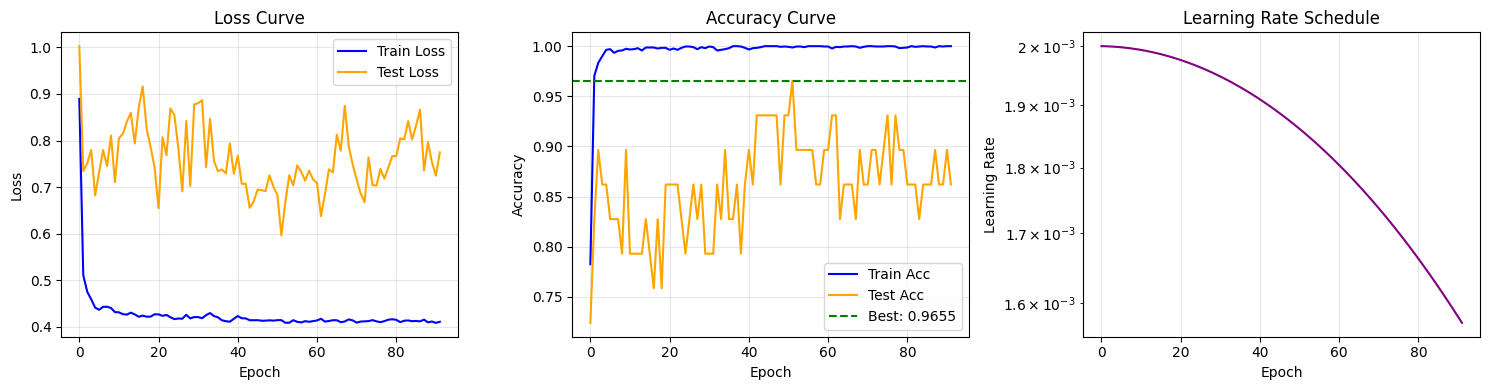

In [39]:
# Plot loss and accuracy curves
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Loss curve
axes[0].plot(train_losses, label="Train Loss", color="blue")
axes[0].plot(test_losses, label="Test Loss", color="orange")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].set_title("Loss Curve")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy curve
axes[1].plot(train_accs, label="Train Acc", color="blue")
axes[1].plot(test_accs, label="Test Acc", color="orange")
axes[1].axhline(
    y=best_acc, color="green", linestyle="--", label=f"Best: {best_acc:.4f}"
)
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].set_title("Accuracy Curve")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Learning rate curve
axes[2].plot(learning_rates, color="purple")
axes[2].set_xlabel("Epoch")
axes[2].set_ylabel("Learning Rate")
axes[2].set_title("Learning Rate Schedule")
axes[2].set_yscale("log")
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(save_dir, "training_curves.png"), dpi=150)
plt.show()

## 8. Evaluation

In [40]:
# Load best model
model.load_state_dict(torch.load(ckpt_path, map_location=DEVICE))

<All keys matched successfully>

In [41]:
log_info("Evaluation ...")
crit = nn.CrossEntropyLoss()
_, te_acc, preds, gts = evaluate(model, test_loader, crit, DEVICE)
log_info(f"Accuracy: {te_acc:.4f}")

# F1 Score
f1_macro = f1_score(gts, preds, average="macro")
f1_weighted = f1_score(gts, preds, average="weighted")
print(f"\nF1 Score (Macro): {f1_macro:.4f}")
print(f"F1 Score (Weighted): {f1_weighted:.4f}")

# Classification Report
label_ids = list(range(NUM_CLASSES))
if len(gts) > 0:
    print("\nClassification Report:")
    print(
        classification_report(
            gts,
            preds,
            labels=label_ids,
            target_names=CLASS_NAMES,
            digits=4,
            zero_division=0,
        )
    )

    # Confusion Matrix
    cm = confusion_matrix(gts, preds, labels=label_ids)
    print("\nConfusion Matrix:")
    hdr = "          " + "  ".join(f"{n[:6]:>6s}" for n in CLASS_NAMES)
    print(hdr)
    for i, row in enumerate(cm):
        print(f"  {CLASS_NAMES[i][:8]:>8s}  " + "  ".join(f"{v:>6d}" for v in row))

[00:42:23] INFO - Evaluation ...
[00:42:23] INFO - Accuracy: 0.9655

F1 Score (Macro): 0.9636
F1 Score (Weighted): 0.9655

Classification Report:
              precision    recall  f1-score   support

        grab     1.0000    0.8333    0.9091         6
     release     1.0000    1.0000    1.0000         6
    swipe_up     0.8333    1.0000    0.9091         5
  swipe_down     1.0000    1.0000    1.0000         5
       noise     1.0000    1.0000    1.0000         7

    accuracy                         0.9655        29
   macro avg     0.9667    0.9667    0.9636        29
weighted avg     0.9713    0.9655    0.9655        29


Confusion Matrix:
            grab  releas  swipe_  swipe_   noise
      grab       5       0       1       0       0
   release       0       6       0       0       0
  swipe_up       0       0       5       0       0
  swipe_do       0       0       0       5       0
     noise       0       0       0       0       7


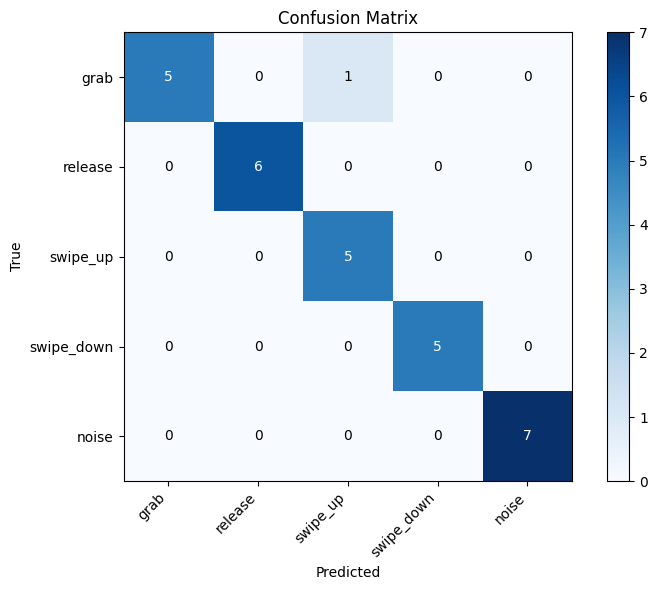

In [42]:
# Plot confusion matrix
fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks(range(NUM_CLASSES))
ax.set_yticks(range(NUM_CLASSES))
ax.set_xticklabels(CLASS_NAMES, rotation=45, ha="right")
ax.set_yticklabels(CLASS_NAMES)
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
ax.set_title("Confusion Matrix")

# Add values
for i in range(NUM_CLASSES):
    for j in range(NUM_CLASSES):
        text = ax.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center",
            color="white" if cm[i, j] > cm.max() / 2 else "black",
        )

plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.savefig(os.path.join(save_dir, "confusion_matrix.png"), dpi=150)
plt.show()

## 9. Save Model Weights

In [43]:
# Save best model
best_path = os.path.join(save_dir, "gesture_tcn_best.pth")
torch.save(model.state_dict(), best_path)
log_info(f"Saved model to {best_path}")

# Save training history
history = {
    "train_losses": train_losses,
    "test_losses": test_losses,
    "train_accs": train_accs,
    "test_accs": test_accs,
    "learning_rates": learning_rates,
    "best_epoch": best_epoch,
    "best_acc": best_acc,
    "f1_macro": f1_macro,
    "f1_weighted": f1_weighted,
}
history_path = os.path.join(save_dir, "training_history.json")
with open(history_path, "w") as f:
    json.dump(history, f, indent=2)
log_info(f"Saved training history to {history_path}")

[00:42:24] INFO - Saved model to checkpoints/gesture_tcn_best.pth
[00:42:24] INFO - Saved training history to checkpoints/training_history.json


In [44]:
# 复制到 Google Drive
import shutil

drive_path = "/content/drive/MyDrive/checkpoints"
shutil.copytree("checkpoints", drive_path, dirs_exist_ok=True)
print(f"文件已复制到: {drive_path}")

文件已复制到: /content/drive/MyDrive/checkpoints


## Summary

This notebook has:
1. Loaded preprocessed data from cache
2. Defined the GestureTCN model
3. Trained the model with early stopping
4. Plotted loss and accuracy curves
5. Evaluated the model with F1 score, classification report, and confusion matrix
6. Saved the best model weights

**Output files:**
- `checkpoints/gesture_tcn_best.pth` - Best model weights
- `checkpoints/training_curves.png` - Training visualization
- `checkpoints/confusion_matrix.png` - Confusion matrix
- `checkpoints/training_history.json` - Training history